# Export Workflow

This notebook shows practical ways to export outputs from the `spafe` Python extension for downstream tools. It covers CSV for tabular workflows, JSON metadata for reproducibility, NumPy `.npz` archives for array workflows, and reload checks.

> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib numpy
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
from __future__ import annotations

import csv
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import spafe

In [2]:
ROOT = Path.cwd()
EXPORT_DIR = ROOT / "target" / "notebook-exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

fs = 16_000
seconds = 1.0
signal = [
    0.7 * math.sin(2.0 * math.pi * 220.0 * n / fs)
    + 0.3 * math.sin(2.0 * math.pi * 880.0 * n / fs)
    for n in range(int(fs * seconds))
]

opts = spafe.FeatureOptions(
    fs=fs,
    nfft=256,
    nfilts=24,
    num_ceps=13,
    win_len=0.025,
    win_hop=0.010,
    normalize="mean_subtraction",
)
print(EXPORT_DIR)

/Users/yehorsmoliakov/Downloads/spafe/notebooks/target/notebook-exports


## Compute Features Once

The extension returns plain Python lists, which can be written directly as CSV or converted to NumPy arrays.

In [3]:
mfcc = spafe.mfcc(signal, opts)
gfcc = spafe.gfcc(signal, opts)
mel = spafe.mel_spectrogram(signal, opts)
pitches, harmonic_rates, argmins, times = spafe.compute_yin(signal, fs=fs)

mfcc_np = np.asarray(mfcc, dtype=np.float64)
gfcc_np = np.asarray(gfcc, dtype=np.float64)
mel_np = np.asarray(mel.features, dtype=np.float64)
pitch_np = np.asarray(pitches, dtype=np.float64)
time_np = np.asarray(times, dtype=np.float64)

print("mfcc", mfcc_np.shape)
print("gfcc", gfcc_np.shape)
print("mel", mel_np.shape)
print("pitch", pitch_np.shape)

mfcc (98, 13)
gfcc (98, 13)
mel (98, 24)
pitch (65,)


## Export CSV

CSV is easy to inspect and works well for spreadsheets or simple data pipelines. Feature matrices are written one row per frame.

In [4]:
def write_matrix_csv(path: Path, matrix: list[list[float]]) -> None:
    with path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerows(matrix)


def write_pitch_csv(path: Path) -> None:
    with path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerow(["time", "pitch", "harmonic_rate", "argmin"])
        writer.writerows(zip(times, pitches, harmonic_rates, argmins))


write_matrix_csv(EXPORT_DIR / "mfcc.csv", mfcc)
write_matrix_csv(EXPORT_DIR / "gfcc.csv", gfcc)
write_matrix_csv(EXPORT_DIR / "mel_spectrogram.csv", mel.features)
write_pitch_csv(EXPORT_DIR / "yin_pitch.csv")

for path in sorted(EXPORT_DIR.glob("*.csv")):
    print(path.name, path.stat().st_size, "bytes")

gfcc.csv 27457 bytes
mel_spectrogram.csv 51214 bytes
mfcc.csv 25446 bytes
yin_pitch.csv 3695 bytes


## Export Metadata as JSON

Keep parameters next to the exported arrays so a downstream script can reproduce the extraction setup.

In [5]:
metadata = {
    "sample": {
        "kind": "synthetic_two_tone",
        "seconds": seconds,
        "sample_rate": fs,
        "samples": len(signal),
    },
    "feature_options": {
        "fs": opts.fs,
        "nfft": opts.nfft,
        "nfilts": opts.nfilts,
        "num_ceps": opts.num_ceps,
        "win_len": opts.win_len,
        "win_hop": opts.win_hop,
        "win_type": opts.win_type,
        "normalize": opts.normalize,
        "pre_emph": opts.pre_emph,
    },
    "outputs": {
        "mfcc_shape": list(mfcc_np.shape),
        "gfcc_shape": list(gfcc_np.shape),
        "mel_shape": list(mel_np.shape),
        "pitch_frames": int(pitch_np.shape[0]),
    },
}

metadata_path = EXPORT_DIR / "metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))
print(metadata_path.read_text())

{
  "sample": {
    "kind": "synthetic_two_tone",
    "seconds": 1.0,
    "sample_rate": 16000,
    "samples": 16000
  },
  "feature_options": {
    "fs": 16000,
    "nfft": 256,
    "nfilts": 24,
    "num_ceps": 13,
    "win_len": 0.025,
    "win_hop": 0.01,
    "win_type": "hamming",
    "normalize": "mean_subtraction",
    "pre_emph": true
  },
  "outputs": {
    "mfcc_shape": [
      98,
      13
    ],
    "gfcc_shape": [
      98,
      13
    ],
    "mel_shape": [
      98,
      24
    ],
    "pitch_frames": 65
  }
}


## Export a NumPy Archive

`.npz` stores multiple typed arrays in one file and is usually the most convenient format for Python ML/audio pipelines.

In [6]:
npz_path = EXPORT_DIR / "features.npz"
np.savez_compressed(
    npz_path,
    mfcc=mfcc_np,
    gfcc=gfcc_np,
    mel_spectrogram=mel_np,
    pitch=pitch_np,
    pitch_time=time_np,
    signal=np.asarray(signal, dtype=np.float32),
)
print(npz_path.name, npz_path.stat().st_size, "bytes")

features.npz 24490 bytes


## Reload and Verify

Always check shape and basic value consistency after writing files, especially when exchanging data between tools.

In [7]:
with np.load(npz_path) as loaded:
    reloaded_mfcc = loaded["mfcc"]
    reloaded_pitch = loaded["pitch"]

assert reloaded_mfcc.shape == mfcc_np.shape
assert reloaded_pitch.shape == pitch_np.shape
assert np.allclose(reloaded_mfcc, mfcc_np)

with (EXPORT_DIR / "mfcc.csv").open() as handle:
    csv_rows = [[float(value) for value in row] for row in csv.reader(handle)]

csv_mfcc = np.asarray(csv_rows, dtype=np.float64)
assert csv_mfcc.shape == mfcc_np.shape
assert np.allclose(csv_mfcc, mfcc_np)
print("reload checks passed")

reload checks passed


## Quick Reload Plot

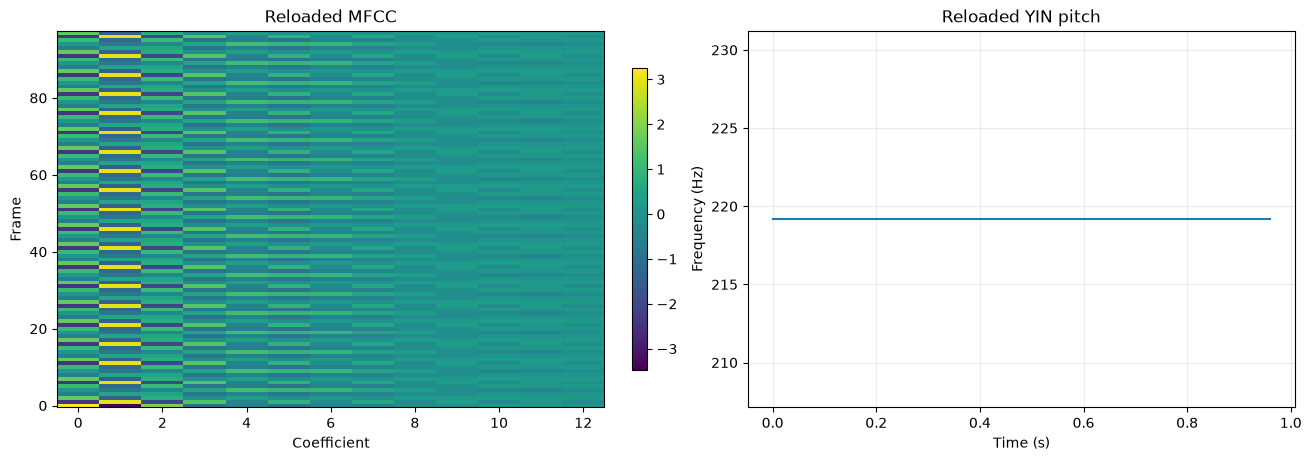

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
image = axes[0].imshow(reloaded_mfcc, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Reloaded MFCC")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Frame")
fig.colorbar(image, ax=axes[0], shrink=0.8)

axes[1].plot(time_np, reloaded_pitch, linewidth=1.5)
axes[1].set_title("Reloaded YIN pitch")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].grid(True, alpha=0.25)
plt.show()

## Export Checklist

- Save arrays and metadata together.
- Include sample rate, window settings, FFT size, filter count, and normalization choices.
- Prefer `.npz` for Python-to-Python pipelines and CSV for spreadsheet/interchange workflows.
- Validate shapes after reload before training or analysis.
- Version exported datasets by changing the output folder or metadata file when options change.